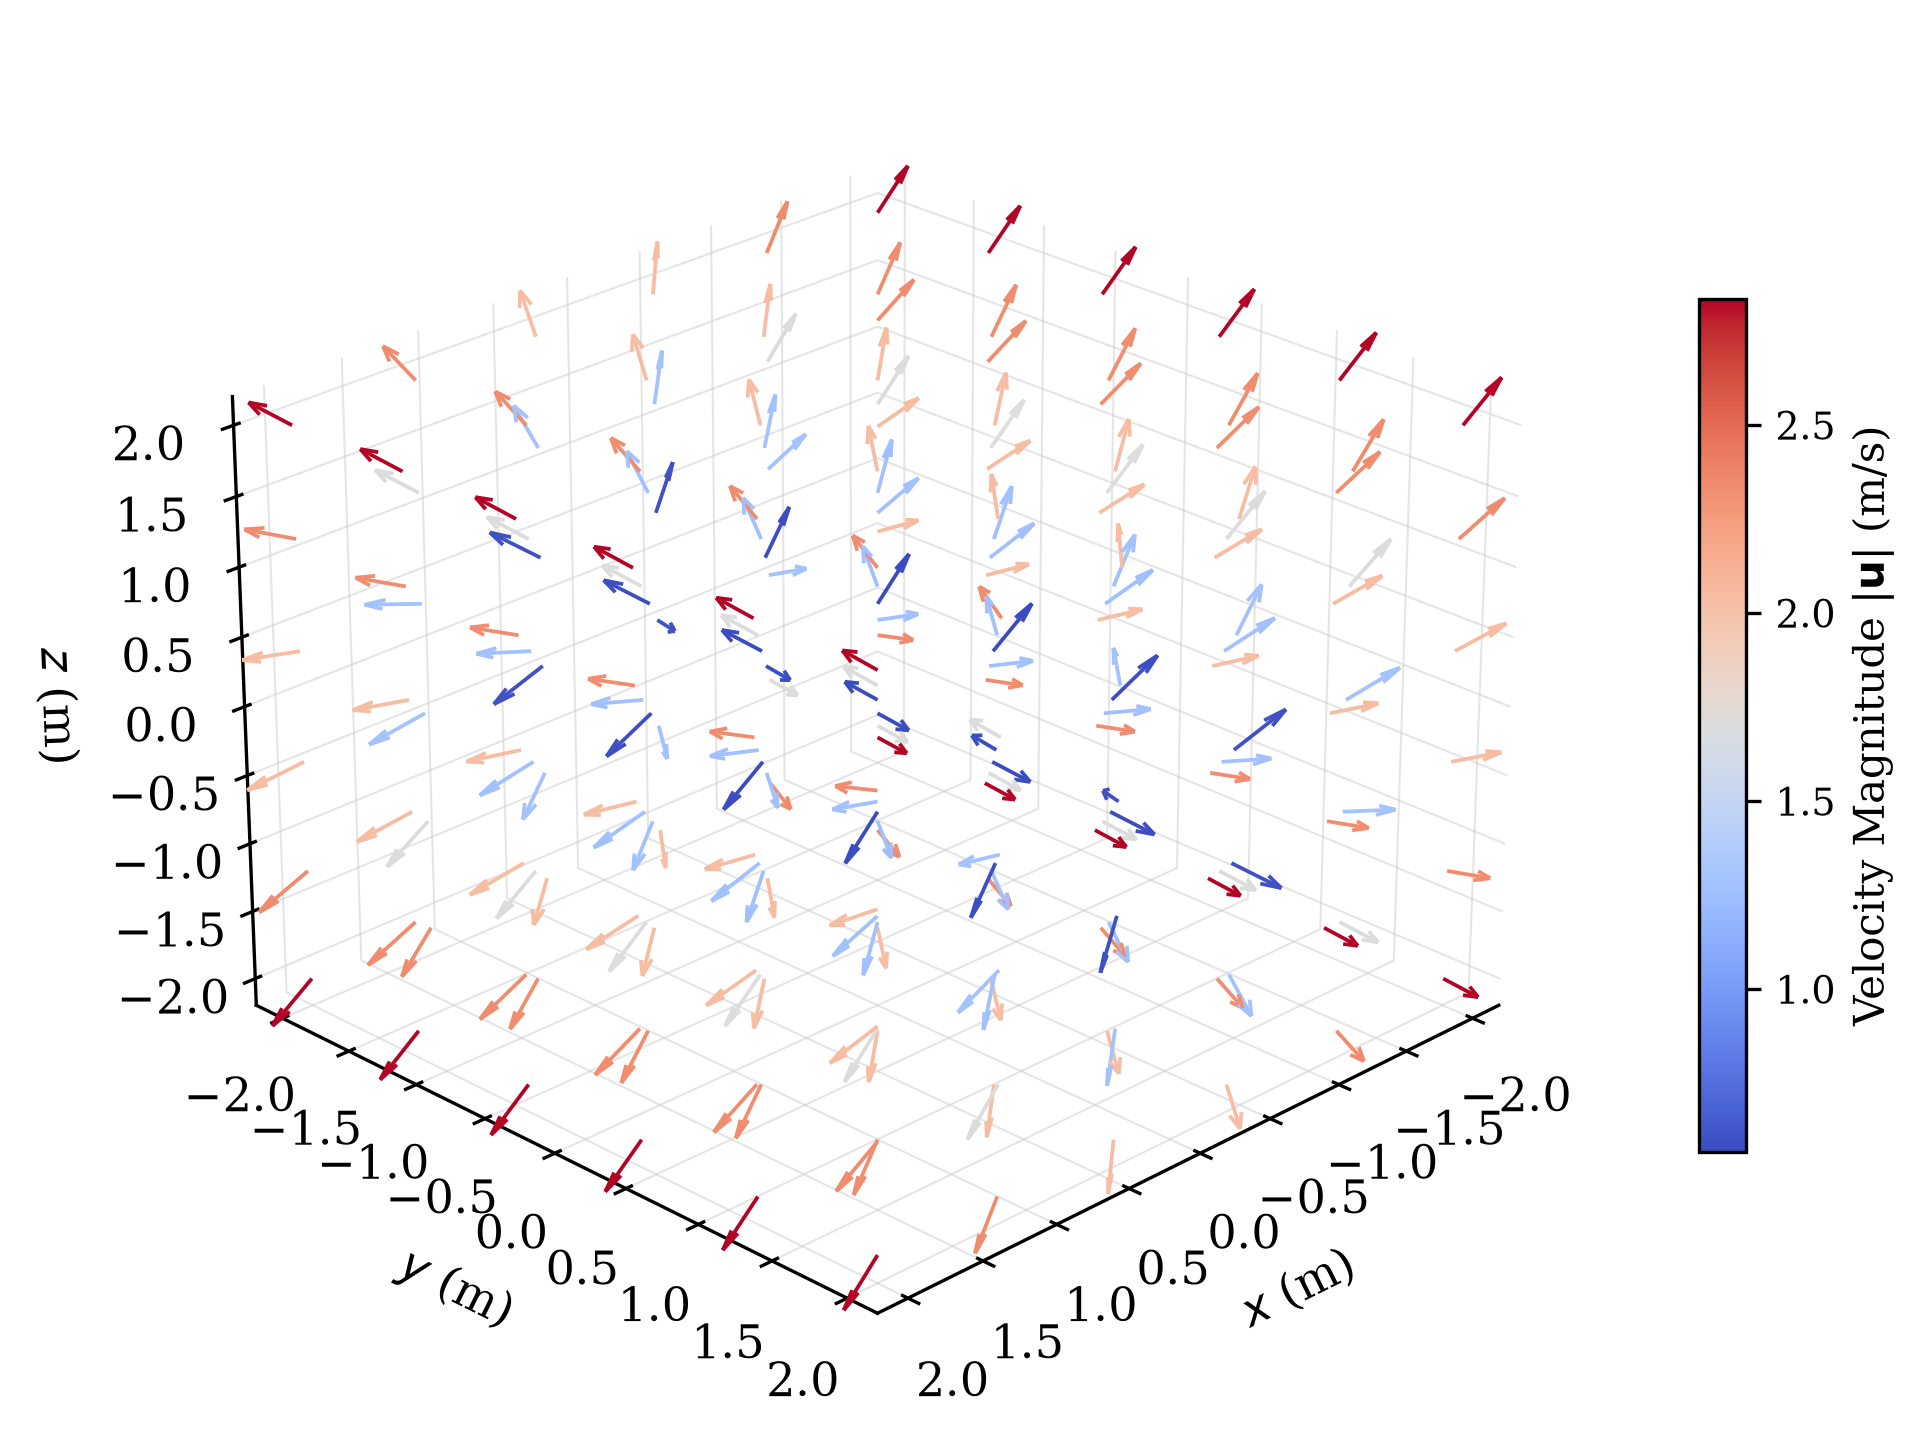

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 严格学术样式全局配置 (Academic Style Setup)
# ==========================================
plt.rcParams.update({
    "text.usetex": False,            # 如果电脑安装了系统级 LaTeX，可设为 True 开启完美数学公式
    "font.family": "serif",          # 选用衬线字体，贴合论文正文
    "font.size": 11,                 # 符合 IEEE 单栏或双栏图片的标准字号
    "axes.linewidth": 0.8,           # 坐标轴边框粗细
    "figure.dpi": 300                # 高清渲染
})

# ==========================================
# 2. 生成物理场数据 (等距 3D 点)
# ==========================================
# 严格控制采样率：8x8x8=512个点，在 3D 中可提供最清晰且不拥挤的视野
x = np.linspace(-2, 2, 6)
y = np.linspace(-2, 2, 6)
z = np.linspace(-2, 2, 6)
X, Y, Z = np.meshgrid(x, y, z)

# 物理方程定义：龙卷风模型 (水平气旋 + 立体发散上升)
U = X
V = Y * 0.1
W = Z

# 计算标量流速 (Speed)，用于严格的色彩密度映射
speed = np.sqrt(U**2 + V**2 + W**2)

# ==========================================
# 3. 3D 画布高级精细化渲染
# ==========================================
fig = plt.figure(figsize=(6.5, 5.5))  # 设定严格的出版尺寸比例
ax = fig.add_subplot(111, projection='3d')

# 使用极为严谨的酷冷到炎热色彩梯度 (coolwarm)，并启用归一化箭头
# arrow_length_ratio 调节箭头箭尖的大小比例，使其显得精细、尖锐
q = ax.quiver(X, Y, Z, U, V, W, 
              length=0.35, 
              cmap='coolwarm', 
              array=speed.flatten(), 
              normalize=True,
              arrow_length_ratio=0.35,
              linewidths=0.9)

# 关键：彻底抹除默认的“塑料灰色”3D 背景面板，变成纯白高透风格
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# 调整网格线，使其变细、半透明，若完全不需要可直接使用 ax.grid(False)
ax.xaxis._axinfo["grid"]['linewidth'] = 0.5
ax.yaxis._axinfo["grid"]['linewidth'] = 0.5
ax.zaxis._axinfo["grid"]['linewidth'] = 0.5
ax.xaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
ax.yaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)
ax.zaxis._axinfo["grid"]['color'] = (0.8, 0.8, 0.8, 0.5)

# 使用数学语法书写标准的坐标轴 Label
ax.set_xlabel(r'$x$ (m)', labelpad=5)
ax.set_ylabel(r'$y$ (m)', labelpad=5)
ax.set_zlabel(r'$z$ (m)', labelpad=5)

# 设置严格的轴坐标显示边界
ax.set_xlim([-2.2, 2.2])
ax.set_ylim([-2.2, 2.2])
ax.set_zlim([-2.2, 2.2])

# 精准微调初始观察视角（elev为仰角，azim为方位角），这是展示 3D 立体感最好的黄金夹角
ax.view_init(elev=25, azim=45)

# 侧边科学色彩指示条 (Colorbar) 精细化配置
cbar = fig.colorbar(q, ax=ax, shrink=0.55, aspect=18, pad=0.08)
cbar.set_label(r'Velocity Magnitude $|\mathbf{u}|$ (m/s)', fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. 定义物理场方程组 F(X) = 0
# ==========================================
def F(X):
    x, y, z = X[0], X[1], X[2]
    # 我们故意设计一个包含正弦波和二次方的复杂三维交叉场
    f1 = x**2 + y**2 + z**2 - 9               # 这是一个半径为3的球面
    f2 = x**2 + y**2 - z**2 - 1               # 这是一个双曲面
    f3 = x + y + np.sin(z) - 1                # 一个波浪形的扭曲平面
    return np.array([f1, f2, f3])

# ==========================================
# 2. 计算雅可比矩阵 (一阶导数矩阵)
# ==========================================
def jacobian(X):
    x, y, z = X[0], X[1], X[2]
    J = np.array([
        [2*x,  2*y,  2*z],
        [2*x,  2*y, -2*z],
        [1.0,  1.0,  np.cos(z)]
    ])
    return J

# ==========================================
# 3. 3D 牛顿迭代器
# ==========================================
def newton_3d_solver(X_guess, tol=1e-6, max_iter=20):
    X = np.array(X_guess, dtype=float)
    history = [X.copy()]
    
    for i in range(max_iter):
        Fx = F(X)
        if np.linalg.norm(Fx) < tol:
            print(f"🎉 牛顿法在第 {i} 次成功收敛！")
            break
            
        J = jacobian(X)
        # 解线性方程组 J * delta_X = -Fx
        delta_X = np.linalg.solve(J, -Fx)
        X += delta_X
        history.append(X.copy())
        
    return np.array(history)

# 执行牛顿迭代，随便猜一个初始位置 [4.0, 3.0, 2.0]
init_guess = [4.0, 3.0, 2.0]
path = newton_3d_solver(init_guess)

# ==========================================
# 4. 建立 3D 差分网格（用来可视化背景空间）
# ==========================================
# 类似 CFD 里的前处理，我们在 [-5, 5] 空间内画满网格
x_grid = np.linspace(-5, 5, 20)
y_grid = np.linspace(-5, 5, 20)
z_grid = np.linspace(-5, 5, 20)
X_mesh, Y_mesh, Z_mesh = np.meshgrid(x_grid, y_grid, z_grid)

# 计算网格中第一个标量场（球面场 f1）的值
# 用于等会儿画一个半透明的“等高壳”来当做空间背景
F1_val = X_mesh**2 + Y_mesh**2 + Z_mesh**2 - 9

# ==========================================
# 5. 使用 Matplotlib 画出惊艳的 3D 视觉图
# ==========================================
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# A. 刻画网格空间：用散点场过滤出函数1的等值面附近区域 (F1_val接近0的点)，模拟云图
mask = np.abs(F1_val) < 1.5
ax.scatter(X_mesh[mask], Y_mesh[mask], Z_mesh[mask], 
           c=Z_mesh[mask], cmap='coolwarm', alpha=0.15, s=10, label='Background Field (Mesh)')

# B. 绘制牛顿迭代的导弹轨迹
px, py, pz = path[:, 0], path[:, 1], path[:, 2]
ax.plot(px, py, pz, color='black', linewidth=2.5, linestyle='-', zorder=10)
# 渐变色画出每一步的点
ax.scatter(px, py, pz, c=range(len(px)), cmap='autumn', s=60, edgecolors='black', zorder=11)

# C. 标记极其关键的起点、迭代点、终点
ax.scatter(px[0], py[0], pz[0], color='lime', marker='^', s=150, label='Start Guess', zorder=12)
ax.scatter(px[-1], py[-1], pz[-1], color='cyan', marker='*', s=250, label='Solution Intersection', zorder=13)

# 装饰图表
ax.set_title("3D Grid & Matrix Newton Method Trajectory", fontsize=14)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-5, 5])
ax.legend(loc='upper left')

# 开启交互视角的提示
print("提示：在弹出的窗口中，你可以按住鼠标左键任意拖动旋转这个三维网格空间！")
plt.show()


SyntaxError: invalid syntax (3638645242.py, line 19)